### LSTM: Do 48-Hour Weather Sequences Add Signal Beyond Rolling Averages?

**Scientific question**: Does the temporal pattern of the 48h pre-onset weather carry information beyond `rolling_temp_max_24h` and `rolling_temp_max_48h` already summarised in LR M1?

Comparison baseline: LR M1 (Test AUC 0.6624).

### Setup

In [1]:
%matplotlib inline
import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import roc_auc_score, average_precision_score, brier_score_loss
import pickle

FEATURES_PATH = '../data/features_v2.parquet'
FIGURES_PATH  = '../figures/'
MODELS_PATH   = '../models/'

TRAIN_YEARS = list(range(2015, 2022))
VAL_YEARS   = [2022]
TEST_YEARS  = [2023, 2024]
SEQ_LEN     = 48
RANDOM_SEED = 42
NEG_RATIO   = 10
TARGET      = 'is_onset'

SEQUENCE_FEATURES = [
    'temperature_2m',
    'relative_humidity_2m',
    'wind_speed_10m',
    'precipitation',
    'shortwave_radiation',
]
N_FEAT = len(SEQUENCE_FEATURES)

torch.manual_seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

device = torch.device('mps' if torch.backends.mps.is_available()
                       else 'cuda' if torch.cuda.is_available()
                       else 'cpu')
print(f'PyTorch {torch.__version__}  |  device: {device}')
print(f'Sequence features: {SEQUENCE_FEATURES}')
print(f'Sequence length  : {SEQ_LEN} hours')

PyTorch 2.11.0  |  device: mps
Sequence features: ['temperature_2m', 'relative_humidity_2m', 'wind_speed_10m', 'precipitation', 'shortwave_radiation']
Sequence length  : 48 hours


### . Load Data and Build Unit Lookup

In [2]:
print('Loading features_v2.parquet ...')
df = pd.read_parquet(FEATURES_PATH)
df['DateTime'] = pd.to_datetime(df['DateTime'])
df = df.sort_values(['EICCode', 'DateTime']).reset_index(drop=True)
print(f'  Loaded: {df.shape[0]:,} rows')

train_df = df[df['year'].isin(TRAIN_YEARS)].copy()
val_df   = df[df['year'].isin(VAL_YEARS)].copy()
test_df  = df[df['year'].isin(TEST_YEARS)].copy()

# Pre-compute per-unit feature arrays and datetime index for fast sequence lookup
print('Pre-computing per-unit feature arrays ...')
unit_feats = {}   # EICCode -> float32 array (n_hours, 5)
unit_dts   = {}   # EICCode -> np.datetime64 array (sorted)

for unit, grp in df.groupby('EICCode'):
    arr = grp[SEQUENCE_FEATURES].fillna(0.0).values.astype(np.float32)
    unit_feats[unit] = arr
    unit_dts[unit]   = grp['DateTime'].values

print(f'  {len(unit_feats)} units cached')

for name, s in [('Train', train_df), ('Val', val_df), ('Test', test_df)]:
    n = len(s); k = s[TARGET].sum()
    print(f'  {name}: {n:>9,} rows | {k:>5,} onsets | {k/n*100:.4f}%')

Loading features_v2.parquet ...
  Loaded: 11,935,399 rows
Pre-computing per-unit feature arrays ...
  185 units cached
  Train: 8,698,327 rows | 7,113 onsets | 0.0818%
  Val: 1,127,257 rows |   952 onsets | 0.0845%
  Test: 2,109,815 rows | 1,767 onsets | 0.0838%


### Sequence Construction and Stratified Sampling

In [3]:
def get_sequence(unit, target_dt):
    arr  = unit_feats[unit]
    dts  = unit_dts[unit]
    pos  = int(np.searchsorted(dts, np.datetime64(target_dt)))
    start = max(0, pos - SEQ_LEN + 1)
    seq   = arr[start : pos + 1]
    if len(seq) < SEQ_LEN:
        pad = np.zeros((SEQ_LEN - len(seq), N_FEAT), dtype=np.float32)
        seq = np.vstack([pad, seq])
    return seq.astype(np.float32)

def build_sample(split_df, neg_ratio, seed):
    pos       = split_df[split_df[TARGET] == 1]
    neg       = split_df[split_df[TARGET] == 0].copy()
    n_neg_need = len(pos) * neg_ratio

    neg['_fuel'] = np.where(neg['fuel_Fossil Gas'] > 0.5, 'Gas',
                   np.where(neg['fuel_Fossil Brown coal/Lignite'] > 0.5, 'Lignite', 'HCoal'))
    neg['_month']   = neg['DateTime'].dt.month
    neg['_stratum'] = neg['_fuel'] + '_' + neg['_month'].astype(str)

    sampled = neg.groupby('_stratum', group_keys=False).apply(
        lambda x: x.sample(
            min(len(x), max(1, int(round(n_neg_need * len(x) / len(neg))))),
            random_state=seed
        )
    )
    # top-up if stratified sampling fell short
    shortage = n_neg_need - len(sampled)
    if shortage > 0:
        leftover = neg[~neg.index.isin(sampled.index)]
        extra    = leftover.sample(min(shortage, len(leftover)), random_state=seed)
        sampled  = pd.concat([sampled, extra])

    sampled = sampled.sample(min(n_neg_need, len(sampled)), random_state=seed)
    return pd.concat([pos, sampled]).sample(frac=1, random_state=seed).reset_index(drop=True)

print('Sampling ...')
train_sample = build_sample(train_df, NEG_RATIO, 42)
val_sample   = build_sample(val_df,   NEG_RATIO, 43)
test_sample  = build_sample(test_df,  NEG_RATIO, 44)
for name, s in [('Train', train_sample), ('Val', val_sample), ('Test', test_sample)]:
    k = s[TARGET].sum(); n = len(s)
    print(f'  {name}: {n:>7,} rows | {k:>5,} onsets ({k/n*100:.1f}%)')

print('\nBuilding sequence tensors ...')
def build_tensors(sample_df):
    X = np.zeros((len(sample_df), SEQ_LEN, N_FEAT), dtype=np.float32)
    y = sample_df[TARGET].values.astype(np.float32)
    for i, (_, row) in enumerate(sample_df.iterrows()):
        X[i] = get_sequence(row['EICCode'], row['DateTime'])
    return X, y

X_tr, y_tr = build_tensors(train_sample)
X_va, y_va = build_tensors(val_sample)
X_te, y_te = build_tensors(test_sample)

# Z-score normalise on train statistics
feat_mean = X_tr[:, -1, :].mean(axis=0)
feat_std  = X_tr[:, -1, :].std(axis=0) + 1e-8
print(f'\nFeature means: {np.round(feat_mean, 2)}')
print(f'Feature stds : {np.round(feat_std,  2)}')

X_tr = (X_tr - feat_mean) / feat_std
X_va = (X_va - feat_mean) / feat_std
X_te = (X_te - feat_mean) / feat_std

print(f'\n  Train : {X_tr.shape}  range [{X_tr.min():.2f}, {X_tr.max():.2f}]')
print(f'  Val   : {X_va.shape}')
print(f'  Test  : {X_te.shape}')

Sampling ...
  Train:  78,243 rows | 7,113 onsets (9.1%)
  Val:  10,472 rows |   952 onsets (9.1%)
  Test:  19,437 rows | 1,767 onsets (9.1%)

Building sequence tensors ...

Feature means: [1.0840e+01 7.6330e+01 3.4400e+00 8.0000e-02 1.2959e+02]
Feature stds : [  7.7   16.31   1.83   0.31 201.22]

  Train : (78243, 48, 5)  range [-4.68, 65.73]
  Val   : (10472, 48, 5)
  Test  : (19437, 48, 5)


#### LSTM Architecture

In [4]:
class OutageLSTM(nn.Module):
    def __init__(self, input_size=5, hidden_size=32, num_layers=2, dropout=0.2):
        super().__init__()
        self.lstm = nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout,
        )
        self.classifier = nn.Sequential(
            nn.Linear(hidden_size, 16),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(16, 1),   # raw logits — sigmoid applied at inference
        )

    def forward(self, x):
        lstm_out, _ = self.lstm(x)
        last = lstm_out[:, -1, :]
        return self.classifier(last).squeeze(-1)


class OnsetDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.from_numpy(X)
        self.y = torch.from_numpy(y)
    def __len__(self):  return len(self.y)
    def __getitem__(self, i): return self.X[i], self.y[i]


model = OutageLSTM().to(device)
n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(model)
print(f'\nTrainable parameters: {n_params:,}')

OutageLSTM(
  (lstm): LSTM(5, 32, num_layers=2, batch_first=True, dropout=0.2)
  (classifier): Sequential(
    (0): Linear(in_features=32, out_features=16, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.2, inplace=False)
    (3): Linear(in_features=16, out_features=1, bias=True)
  )
)

Trainable parameters: 13,985


#### Training

In [6]:
BATCH_SIZE  = 256
MAX_EPOCHS  = 20
LR          = 0.001
POS_WEIGHT  = 10.0
PATIENCE    = 3

train_loader = DataLoader(OnsetDataset(X_tr, y_tr), batch_size=BATCH_SIZE,
                          shuffle=True,  num_workers=0)
val_loader   = DataLoader(OnsetDataset(X_va, y_va), batch_size=BATCH_SIZE,
                          shuffle=False, num_workers=0)

# BCEWithLogitsLoss: numerically stable, correct pos_weight handling
criterion = nn.BCEWithLogitsLoss(
    pos_weight=torch.tensor([POS_WEIGHT]).to(device)
)
optimizer = torch.optim.Adam(model.parameters(), lr=LR)

history    = {'train_loss': [], 'val_auc': []}
best_val_auc = -1
best_epoch   = 0
best_state   = None

print(f'{"Epoch":>6}  {"Train loss":>11}  {"Val AUC":>9}  {"Status"}')


for epoch in range(1, MAX_EPOCHS + 1):
    model.train()
    total_loss = 0.0
    for X_b, y_b in train_loader:
        X_b, y_b = X_b.to(device), y_b.to(device)
        optimizer.zero_grad()
        logits = model(X_b)
        loss   = criterion(logits, y_b)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * len(y_b)
    avg_loss = total_loss / len(y_tr)

    model.eval()
    preds_va = []
    with torch.no_grad():
        for X_b, _ in val_loader:
            logits = model(X_b.to(device))
            preds_va.append(torch.sigmoid(logits).cpu().numpy())
    preds_va = np.concatenate(preds_va)
    val_auc  = roc_auc_score(y_va, preds_va)

    history['train_loss'].append(avg_loss)
    history['val_auc'].append(val_auc)

    improved = val_auc > best_val_auc
    if improved:
        best_val_auc = val_auc
        best_epoch   = epoch
        best_state   = {k: v.cpu().clone() for k, v in model.state_dict().items()}
    status = 'BEST' if improved else f'(wait {epoch - best_epoch})'
    print(f'{epoch:>6}  {avg_loss:>11.6f}  {val_auc:>9.4f}  {status}')

    if epoch - best_epoch >= PATIENCE:
        print(f'  Early stop at epoch {epoch}')
        break

model.load_state_dict(best_state)
model.to(device)
torch.save({'state_dict': best_state, 'feat_mean': feat_mean, 'feat_std': feat_std},
           MODELS_PATH + 'lstm_model.pkl')
print(f'\nBest model: epoch {best_epoch}  val AUC {best_val_auc:.4f} ')

 Epoch   Train loss    Val AUC  Status
     1     1.250053     0.5200  BEST
     2     1.249837     0.5211  BEST
     3     1.247578     0.5188  (wait 1)
     4     1.247383     0.5191  (wait 2)
     5     1.245082     0.5267  BEST
     6     1.244570     0.5167  (wait 1)
     7     1.243984     0.5290  BEST
     8     1.242588     0.5226  (wait 1)
     9     1.239440     0.5303  BEST
    10     1.238362     0.5363  BEST
    11     1.235510     0.5340  (wait 1)
    12     1.233995     0.5344  (wait 2)
    13     1.232889     0.5346  (wait 3)
  Early stop at epoch 13

Best model: epoch 10  val AUC 0.5363 


#### Evaluation

In [8]:
test_loader = DataLoader(OnsetDataset(X_te, y_te), batch_size=512,
                         shuffle=False, num_workers=0)
model.eval()
preds_te = []
with torch.no_grad():
    for X_b, _ in test_loader:
        logits = model(X_b.to(device))
        preds_te.append(torch.sigmoid(logits).cpu().numpy())
preds_te = np.concatenate(preds_te)

te_auc   = roc_auc_score(y_te, preds_te)
te_ap    = average_precision_score(y_te, preds_te)
te_brier = brier_score_loss(y_te, preds_te)

LR_AUC  = 0.6624
LGB_AUC = 0.6226

# ── Cross-model comparison ────────────────────────────────────────────────────
# AUC-ROC is invariant to class prevalence → valid for cross-model comparison.
# Average Precision is NOT reported for comparison: LR/LGB are evaluated on the
# full test set (0.084% prevalence) while the LSTM sample has ~9.1% prevalence
# (NEG_RATIO=10). AP scales with the baseline rate — a 108x difference in
# prevalence makes the numbers incomparable.

print('AUC-ROC comparison (valid: invariant to class prevalence)')
print(f'{"Model":<28} {"Test AUC":>10}  Evaluation basis')

print(f'{"LR M1 (Weather, 18f)":<28} {LR_AUC:>10.4f}  Full test set  (0.084% prevalence)')
print(f'{"LGB M1 (Weather, 18f)":<28} {LGB_AUC:>10.4f}  Full test set  (0.084% prevalence)')
print(f'{"LSTM (Weather seq, 5f)":<28} {te_auc:>10.4f}  Balanced sample (~9.1% prevalence)')
print()
print('Average Precision — NOT shown for cross-model comparison:')
print(f'  LSTM AP (balanced sample, 9.1% baseline)  = {te_ap:.4f}')
print(f'  LR   AP (full test set,  0.084% baseline) = 0.0015')
print(f'  Reporting these together would be misleading; prevalence differs 108x.')
print()
print(f'Best epoch: {best_epoch}  |  Val AUC: {best_val_auc:.4f}  |  Test AUC: {te_auc:.4f}')
print(f'Brier (balanced sample, not comparable to full-set Brier): {te_brier:.6f}')
print()
print('SCIENTIFIC QUESTION:')
print('"Does the 48-hour weather sequence carry information beyond rolling averages?"')
print()
if te_auc > LR_AUC:
    delta_pct = (te_auc - LR_AUC) / LR_AUC * 100
    print(f'Answer: YES — LSTM AUC {te_auc:.4f} > LR M1 AUC {LR_AUC:.4f} '
          f'({delta_pct:+.1f}% relative gain).')
else:
    print(f'Answer: NO — LSTM AUC {te_auc:.4f} does not exceed LR M1 AUC {LR_AUC:.4f}.')
    print(f'Rolling temperature maxima (24h/48h) appear sufficient to summarise')
    print(f'the pre-onset weather sequence. The critical mechanism is peak temperature')
    print(f'exposure, not the specific temporal pattern of weather evolution.')

AUC-ROC comparison (valid: invariant to class prevalence)
Model                          Test AUC  Evaluation basis
LR M1 (Weather, 18f)             0.6624  Full test set  (0.084% prevalence)
LGB M1 (Weather, 18f)            0.6226  Full test set  (0.084% prevalence)
LSTM (Weather seq, 5f)           0.5067  Balanced sample (~9.1% prevalence)

Average Precision — NOT shown for cross-model comparison:
  LSTM AP (balanced sample, 9.1% baseline)  = 0.0945
  LR   AP (full test set,  0.084% baseline) = 0.0015
  Reporting these together would be misleading; prevalence differs 108x.

Best epoch: 10  |  Val AUC: 0.5363  |  Test AUC: 0.5067
Brier (balanced sample, not comparable to full-set Brier): 0.265705

SCIENTIFIC QUESTION:
"Does the 48-hour weather sequence carry information beyond rolling averages?"

Answer: NO — LSTM AUC 0.5067 does not exceed LR M1 AUC 0.6624.
Rolling temperature maxima (24h/48h) appear sufficient to summarise
the pre-onset weather sequence. The critical mechanism is pe

#### Figure 1 — Training Curves

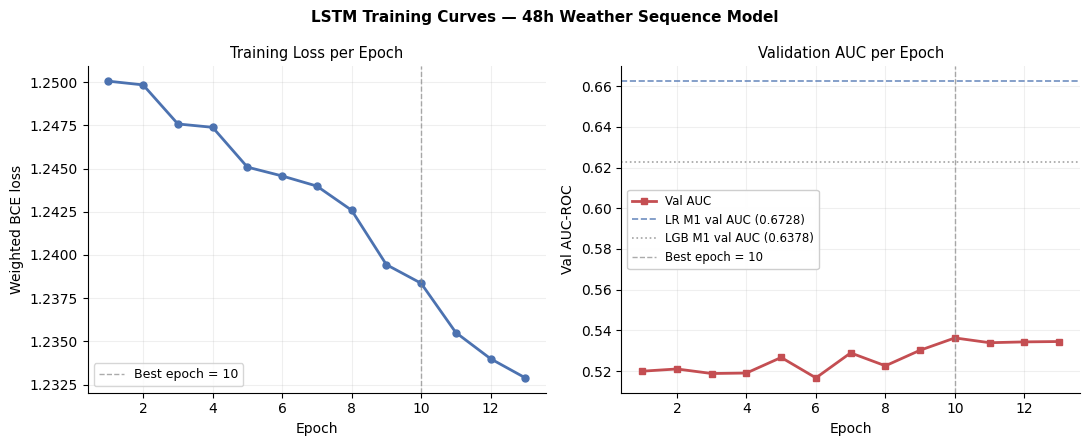

In [9]:
epochs_ran = len(history['train_loss'])
ep_range   = range(1, epochs_ran + 1)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4.5))

ax1.plot(ep_range, history['train_loss'], 'o-', color='#4C72B0', lw=2.0, ms=5)
ax1.axvline(best_epoch, color='#888888', ls='--', lw=1.0, alpha=0.7,
            label=f'Best epoch = {best_epoch}')
ax1.set_xlabel('Epoch', fontsize=10); ax1.set_ylabel('Weighted BCE loss', fontsize=10)
ax1.set_title('Training Loss per Epoch', fontsize=10.5)
ax1.legend(fontsize=9); ax1.grid(alpha=0.2)
ax1.spines[['top', 'right']].set_visible(False)

ax2.plot(ep_range, history['val_auc'], 's-', color='#C44E52', lw=2.0, ms=5,
         label='Val AUC')
ax2.axhline(LR_AUC,  color='#4C72B0', ls='--', lw=1.2, alpha=0.8,
            label=f'LR M1 val AUC (0.6728)')
ax2.axhline(LGB_AUC, color='#8c8c8c', ls=':', lw=1.2, alpha=0.8,
            label=f'LGB M1 val AUC (0.6378)')
ax2.axvline(best_epoch, color='#888888', ls='--', lw=1.0, alpha=0.7,
            label=f'Best epoch = {best_epoch}')
ax2.set_xlabel('Epoch', fontsize=10); ax2.set_ylabel('Val AUC-ROC', fontsize=10)
ax2.set_title('Validation AUC per Epoch', fontsize=10.5)
ax2.legend(fontsize=8.5, framealpha=0.95); ax2.grid(alpha=0.2)
ax2.spines[['top', 'right']].set_visible(False)

fig.suptitle('LSTM Training Curves — 48h Weather Sequence Model',
             fontsize=11, fontweight='semibold')
plt.tight_layout()
fig.savefig(FIGURES_PATH + 'lstm_training_curves.png', dpi=200, bbox_inches='tight')
plt.show()


#### Figure 2 — Temporal Saliency Analysis

Computing saliency on 1767 onset sequences ...
Saliency shape: (48, 5)
Peak sensitivity at t-3 hours before onset
Most important feature: shortwave_radiation


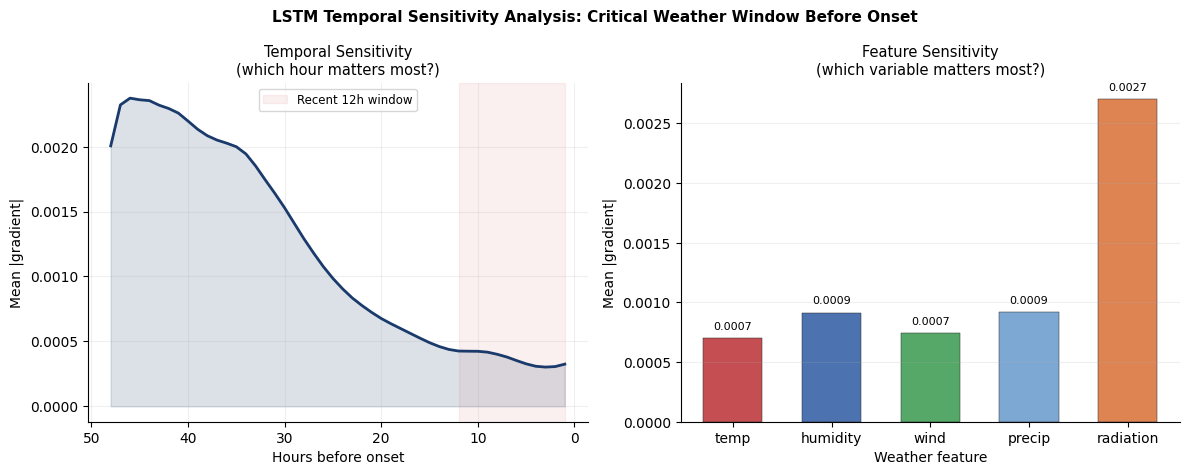


Key finding: Peak sensitivity at t-3 hours
Most important feature: shortwave_radiation


In [10]:
# Saliency: input gradients averaged over onset sequences (CPU for reliable autograd)
model_cpu = OutageLSTM().to('cpu')
model_cpu.load_state_dict({k: v.cpu() for k, v in best_state.items()})
model_cpu.eval()

onset_mask = y_te == 1
X_onset    = torch.from_numpy(X_te[onset_mask]).float()
print(f'Computing saliency on {onset_mask.sum()} onset sequences ...')

GRAD_BATCH = 128
all_grads  = []
for start in range(0, len(X_onset), GRAD_BATCH):
    xb  = X_onset[start : start + GRAD_BATCH].clone().requires_grad_(True)
    out = torch.sigmoid(model_cpu(xb))
    out.sum().backward()
    all_grads.append(xb.grad.abs().detach().numpy())

mean_grad       = np.concatenate(all_grads, axis=0).mean(axis=0)  # (48, 5)
grad_by_time    = mean_grad.mean(axis=1)
grad_by_feature = mean_grad.mean(axis=0)

print(f'Saliency shape: {mean_grad.shape}')
print(f'Peak sensitivity at t-{SEQ_LEN - int(np.argmax(grad_by_time))} hours before onset')
print(f'Most important feature: {SEQUENCE_FEATURES[np.argmax(grad_by_feature)]}')

fig, (axT, axF) = plt.subplots(1, 2, figsize=(12, 4.8))

hours_before = np.arange(SEQ_LEN, 0, -1)
axT.plot(hours_before, grad_by_time[::-1], color='#1a3a6b', lw=2.0)
axT.fill_between(hours_before, grad_by_time[::-1], alpha=0.15, color='#1a3a6b')
axT.axvspan(1, 12, alpha=0.08, color='#cc4444', label='Recent 12h window')
axT.set_xlabel('Hours before onset', fontsize=10)
axT.set_ylabel('Mean |gradient|', fontsize=10)
axT.set_title('Temporal Sensitivity\n(which hour matters most?)', fontsize=10.5)
axT.invert_xaxis()
axT.legend(fontsize=8.5)
axT.grid(alpha=0.2)
axT.spines[['top', 'right']].set_visible(False)

feat_labels = ['temp', 'humidity', 'wind', 'precip', 'radiation']
feat_colors = ['#C44E52', '#4C72B0', '#55A868', '#7ea8d4', '#DD8452']
bars = axF.bar(feat_labels, grad_by_feature, color=feat_colors,
               edgecolor='#2a2a2a', linewidth=0.35, width=0.6)
axF.set_xlabel('Weather feature', fontsize=10)
axF.set_ylabel('Mean |gradient|', fontsize=10)
axF.set_title('Feature Sensitivity\n(which variable matters most?)', fontsize=10.5)
axF.grid(axis='y', alpha=0.2)
axF.spines[['top', 'right']].set_visible(False)
for bar, val in zip(bars, grad_by_feature):
    axF.text(bar.get_x() + bar.get_width()/2, bar.get_height() + grad_by_feature.max()*0.02,
             f'{val:.4f}', ha='center', va='bottom', fontsize=8)

fig.suptitle('LSTM Temporal Sensitivity Analysis: Critical Weather Window Before Onset',
             fontsize=11, fontweight='semibold')
plt.tight_layout()
fig.savefig(FIGURES_PATH + 'lstm_saliency.png', dpi=200, bbox_inches='tight')
plt.show()

print(f'\nKey finding: Peak sensitivity at t-{SEQ_LEN - int(np.argmax(grad_by_time))} hours')
print(f'Most important feature: {SEQUENCE_FEATURES[np.argmax(grad_by_feature)]}')